In [1]:
import pandas as pd
import numpy as np


In [2]:
imoveis_df = pd.read_csv("csv files/imoveisTraining.csv")
imoveis_df.head(10)

,Bairro,Numero de quartos,Metros quadrados,Vagas de Garagem,Numero de Banheiros,Preço
0,Recanto do Salto,4,319,2,5,3890000
1,Jardim Nações Unidas,2,45,1,1,155000
2,Jardim São Jorge,3,159,2,4,1715000
3,Marumbi,4,191,4,4,1390000
4,Gleba Fazenda Palhano,2,62,1,2,615000
5,Petrópolis,4,610,1,2,1100000
6,Centro,3,96,1,2,500000
7,Jardim Morumbi,3,196,2,5,1500000
8,Brasília,2,70,1,2,330000
9,Catuai,3,80,2,1,280000


<p style="text-align: center;">Com os dados preparados, minha primeira escolha de modelo para resolver esse problema de previsão de preços de imóveis foi um algoritmo de regressão linear, mais especificamente a regressão Ridge por conta da regularização do coeficiente L2, que permite a redução de overfitting e trabalha melhor com colinearidade. Por conta de ser um modelo mais simples ele será minha baseline para testar outros modelos. </p>

<p style="text-align: center;">Com isso, decidi as features a serem utilizadas. Com base em outras soluções e também para efeitos de teste, utilizei todas as features de teste iniciais dos dados, que são número de quartos, metros quadrados, vagas de garagem e numero de banheiros. Depois, eu testarei com mais uma feature que será o bairro, e utilizarei one hot encoding para isso. </p>

In [3]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from time import process_time

np.random.seed(76000)
X_original = imoveis_df.drop(["Preço", "Bairro"], axis=1)
y_original = imoveis_df["Preço"]

X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X_original, y_original, test_size = 0.2)
clf_ridge_original = Ridge()

start = process_time()
clf_ridge_original.fit(X_train_original, y_train_original)
end = process_time()

y_preds_ridge_original = clf_ridge_original.predict(X_test_original)

r2_score_ridge_original = r2_score(y_test_original, y_preds_ridge_original)
mae_score_ridge_original = mean_absolute_error(y_test_original, y_preds_ridge_original)
mse_score_ridge_original = mean_squared_error(y_test_original, y_preds_ridge_original)


print(f"R2 score Ridge: {r2_score_ridge_original}")
print(f"MAE score Ridge: {mae_score_ridge_original}")
print(f"MSE score Ridge: {mse_score_ridge_original}")
print(f"Com tempo de {end - start} segundos")



R2 score Ridge: 0.5942910618106965
MAE score Ridge: 405706.4696074236
MSE score Ridge: 534527987282.2959
Com tempo de 0.171875 segundos


<p style="text-align: center;">Como não funcionou bem sem a feature de bairros, irei fazer o one hot encoding e tentar novamente. </p>


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

np.random.seed(76000)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output = False).set_output(transform='pandas')
bairros = imoveis_df[["Bairro"]]
ohe_transform = ohe.fit_transform(bairros)




X_ohe = pd.concat([imoveis_df, ohe_transform], axis=1).drop(["Preço", "Bairro"], axis=1)
y_ohe = imoveis_df["Preço"]
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_ohe, y_ohe, test_size = 0.2)






clf_ridge_ohe = Ridge()
start = process_time()
clf_ridge_ohe.fit(X_train_ohe, y_train_ohe)
end = process_time()

y_preds_ridge_ohe = clf_ridge_ohe.predict(X_test_ohe) 


r2_score_ridge_ohe = r2_score(y_test_ohe, y_preds_ridge_ohe)
mae_score_ridge_ohe = mean_absolute_error(y_test_ohe, y_preds_ridge_ohe)
mse_score_ridge_ohe = mean_squared_error(y_test_ohe, y_preds_ridge_ohe)



print(f"R2 score Ridge: {r2_score_ridge_ohe}")
print(f"MAE score Ridge: {mae_score_ridge_ohe}")
print(f"MSE score Ridge: {mse_score_ridge_ohe}")
print(f"Com tempo de {end - start} segundos")


R2 score Ridge: 0.7371049737245436
MAE score Ridge: 309282.00401484617
MSE score Ridge: 346368383917.57886
Com tempo de 1.640625 segundos


<p style="text-align: center;">Tentando melhorar o resultado final com diferentes hiperparametros alpha </p>



In [5]:
param_grid_ridge_ohe = {
    "alpha": np.linspace(0, 10, 11)
}
np.random.seed(100)


start = process_time()
grid_search_ridge_ohe = GridSearchCV(clf_ridge_ohe, param_grid_ridge_ohe, cv=5, verbose = 2, n_jobs=-1)
grid_search_ridge_ohe.fit(X_train_ohe, y_train_ohe)
end = process_time()

y_preds_ridge_ohe = grid_search_ridge_ohe.predict(X_test_ohe)

r2_score_ridge_ohe = r2_score(y_test_ohe, y_preds_ridge_ohe)
mae_score_ridge_ohe = mean_absolute_error(y_test_ohe, y_preds_ridge_ohe)
mse_score_ridge_ohe = mean_squared_error(y_test_ohe, y_preds_ridge_ohe)



print(f"R2 score Ridge: {r2_score_ridge_ohe}")
print(f"MAE score Ridge: {mae_score_ridge_ohe}")
print(f"MSE score Ridge: {mse_score_ridge_ohe}")
print(f"Best score Ridge: {grid_search_ridge_ohe.best_params_}")
print(f"Com tempo de {end - start} segundos")


Fitting 5 folds for each of 11 candidates, totalling 55 fits
R2 score Ridge: 0.7371049737245436
MAE score Ridge: 309282.00401484617
MSE score Ridge: 346368383917.57886
Best score Ridge: {'alpha': np.float64(1.0)}
Com tempo de 1.234375 segundos


<p style="text-align: center;">Podemos perceber que houve um aumento muito grande no R2 score, com 0.73, indicando que 73% da diferença entre nossos dados podem ser explicadas, além de diminuir o erro médio absoluto e erro médio quadrático das previsões. Uma melhora considerável de quando não havia a feature de bairro. Com isso, há espaço para melhora, então irei mudar de algoritmos de regressão linear para utilizar um algoritmo de ensemble: Random Forest. O Random Forest para regressão é mais robusto, não varia tanto com outliers que nem o Ridge, portanto é possível que ele performe melhor</p>

<p style="text-align: center;">Antes de treinar o modelo, irei testar se ele de fato vai performar melhor que o Ridge. Irei utilizar o Cross-validation para verificar os scores em diferentes "dobras" do meu conjunto de treino. Esse cross-validation vai pegar o meu conjunto de treino e separar ele em 80% treino e 20% teste de 5 maneiras diferentes e irá treinar e testar o modelo e me retornar o score de cada dobra feita. Com isso, poderei ter uma boa visão se o Random Forest de fato é a melhor opção antes de começar o treinamento</p>

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

np.random.seed(100)

clf_random_forest_ohe = RandomForestRegressor()


scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error'
}

start = process_time()

resultados = cross_validate(clf_random_forest_ohe, X_train_ohe, y_train_ohe, 
                            scoring=scoring, 
                            cv=5, 
                            return_train_score=False)
end = process_time()


print(f"R² por fold:{resultados['test_r2']}")
print(f"MAE por fold: {-resultados['test_mae']}")   
print(f"MSE por fold: {-resultados['test_mse']}")   

print("\nMédias:")
print(f"R² médio: {resultados['test_r2'].mean()}")
print(f"MAE médio: {-resultados['test_mae'].mean()}")
print(f"MSE médio: {-resultados['test_mse'].mean()}")
print(f"Folding durou {end - start} segundos")


R² por fold:[0.92197189 0.84007937 0.85582385 0.90240685 0.90674647]
MAE por fold: [156400.62577525 164934.63392003 150829.17286503 163280.91009937
 146364.00607688]
MSE por fold: [1.18935649e+11 2.56003663e+11 1.67386138e+11 1.68051935e+11
 1.29697398e+11]

Médias:
R² médio: 0.8854056885041693
MAE médio: 156361.86974731117
MSE médio: 168014956550.1314
Folding durou 60.546875 segundos


<p style="text-align: center;">Com o R² médio de 0.88, pudemos observar que ele de fato é mais efetivo que o Ridge, e portanto devemos prosseguir com o treinamento do nosso modelo</p>

In [7]:
start = process_time()
clf_random_forest_ohe.fit(X_train_ohe, y_train_ohe)
end = process_time()

print(f"Com tempo de {end - start} segundos")

R2 score Random Forest: 0.8874115627714928
MAE score Random Forest: 153285.67205932146
MSE score Random Forest: 148337059103.52
Com tempo de 16.484375 segundos


<p style="text-align: center;">Tentando melhorar os hiperparâmetros do Random Forest</p>

In [8]:
param_grid_rf_ohe = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

start = process_time()
grid_search_ohe = GridSearchCV(clf_random_forest_ohe, param_grid_rf_ohe, cv=5, verbose = 2, n_jobs=-1)
grid_search_ohe.fit(X_train_ohe, y_train_ohe)
end = process_time()


Fitting 5 folds for each of 27 candidates, totalling 135 fits


### Salvando o modelo para não ter que treinar ele toda vez

In [23]:
import joblib
joblib.dump(clf_random_forest_ohe, 'model/imoveis_prediction_rf_model.joblib');


In [24]:
clf_random_forest_ohe = joblib.load('model/imoveis_prediction_rf_model.joblib')


### Previsões 

In [25]:
y_preds_rf_ohe = clf_random_forest_ohe.predict(X_test_ohe)

r2_score_rf_ohe = r2_score(y_test_ohe, y_preds_rf_ohe)
mae_score_rf_ohe = mean_absolute_error(y_test_ohe, y_preds_rf_ohe)
mse_score_rf_ohe = mean_squared_error(y_test_ohe, y_preds_rf_ohe)


print(f"R2 score Random Forest: {r2_score_rf_ohe}")
print(f"MAE score Random Forest: {mae_score_rf_ohe}")
print(f"MSE score Random Forest: {mse_score_rf_ohe}")

R2 score Random Forest: 0.8874115627714928
MAE score Random Forest: 153285.67205932146
MSE score Random Forest: 148337059103.52


In [22]:
y_preds_rf_ohe_optimal = grid_search_ohe.predict(X_test_ohe)

r2_score_rf_ohe_optimal = r2_score(y_test_ohe, y_preds_rf_ohe_optimal)
mae_score_rf_ohe_optimal = mean_absolute_error(y_test_ohe, y_preds_rf_ohe_optimal)
mse_score_rf_ohe_optimal = mean_squared_error(y_test_ohe, y_preds_rf_ohe_optimal)


print(f"R2 score Random Forest: {r2_score_rf_ohe_optimal}")
print(f"MAE score Random Forest: {mae_score_rf_ohe_optimal}")
print(f"MSE score Random Forest: {mse_score_rf_ohe_optimal}")
print(grid_search_ohe.best_params_)

R2 score Random Forest: 0.8864240840860397
MAE score Random Forest: 164080.5529967455
MSE score Random Forest: 149638077997.94012
{'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 300}


<p style="text-align: center;">A escolha de hiperparâmetros não deu certo, piorando um pouco o modelo, além de ter demorado muito tempo. Porém, o primeiro resultado que conseguimos já é bom o suficiente para utilizar. Conseguimos explicar 89% das diferenças entre as features dos dados, além de ter um erro médio na previsão de 150.000 reais. Agora iremos analisar as predições, para termos uma noção visual do quão perto de acertar o preço o modelo está</p>

In [10]:
np.random.seed(76000)

X_view = imoveis_df.drop(["Preço"], axis=1)
y_view = imoveis_df["Preço"]

X_train_view, X_test_view, y_train_view, y_test_view = train_test_split(X_view, y_view, test_size = 0.2)


X_test_view["Preço"] = y_test_view
X_test_view["Predição"] = y_preds_rf_ohe.round(0)




In [11]:
centro_view = X_test_view[X_test_view["Bairro"] == "Centro"]
centro_view.head()
len(centro_view)

423

In [12]:
bela_suica_view = X_test_view[X_test_view["Bairro"] == "Bela Suiça"]
bela_suica_view.head()

,Bairro,Numero de quartos,Metros quadrados,Vagas de Garagem,Numero de Banheiros,Preço,Predição
11450,Bela Suiça,2,88,2,2,590000,952369.0
6166,Bela Suiça,3,232,4,4,3300000,2831654.0
785,Bela Suiça,3,115,2,2,1180000,1173677.0
5095,Bela Suiça,2,69,2,2,565000,570652.0
7520,Bela Suiça,3,95,1,1,580000,498090.0


In [13]:
gleba_view = X_test_view[X_test_view["Bairro"] == "Gleba Fazenda Palhano"]
gleba_view.head(8)

,Bairro,Numero de quartos,Metros quadrados,Vagas de Garagem,Numero de Banheiros,Preço,Predição
13006,Gleba Fazenda Palhano,3,76,1,2,530000,560682.0
15392,Gleba Fazenda Palhano,2,103,2,3,1180000,1041522.0
3138,Gleba Fazenda Palhano,3,79,2,2,630000,605674.0
12368,Gleba Fazenda Palhano,3,95,2,3,560000,680103.0
2546,Gleba Fazenda Palhano,3,81,2,1,730000,3945267.0
4754,Gleba Fazenda Palhano,3,125,2,2,1200000,1139772.0
15596,Gleba Fazenda Palhano,4,225,3,5,2998125,2425082.0
4418,Gleba Fazenda Palhano,3,136,2,4,1600000,1535744.0


In [14]:
padovani_view = X_test_view[X_test_view["Bairro"] == "Jardim Padovani"]
padovani_view.head()

,Bairro,Numero de quartos,Metros quadrados,Vagas de Garagem,Numero de Banheiros,Preço,Predição
612,Jardim Padovani,3,70,1,1,260000,272368.0
3763,Jardim Padovani,2,77,1,2,270000,282629.0


In [15]:
sa_view = X_test_view[X_test_view["Bairro"] == "Jardim Sérgio Antônio"]
sa_view.head()

,Bairro,Numero de quartos,Metros quadrados,Vagas de Garagem,Numero de Banheiros,Preço,Predição
16073,Jardim Sérgio Antônio,4,113,5,3,450000,526036.0
14417,Jardim Sérgio Antônio,2,44,1,1,170000,159968.0


In [16]:
samePredict = X_test_view.groupby('Predição').filter(lambda x: len(x) > 1)
samePredict = samePredict.sort_values(by="Predição")

samePredict.head()[:50]

,Bairro,Numero de quartos,Metros quadrados,Vagas de Garagem,Numero de Banheiros,Preço,Predição
21219,Perobinha,2,43,1,1,75000,96170.0
5378,Perobinha,2,43,1,1,115000,96170.0
14881,Perobinha,2,43,1,1,110000,96170.0
7800,Perobinha,2,43,1,1,130000,96170.0
12819,Olímpico,2,41,1,1,185000,120297.0


<p style="text-align: center;">Os exemplos acima foram um com um número grande de exemplares no treino, que é o do bairro Centro com mais de 2000 exemplares(400 nos conjuntos de teste) e outro com menos exemplares de teste, que é o Jardim Padovani, que só possui 10 exemplares(2 nos conjuntos de teste). Com essas views, pudemos perceber que as predições estão boas, ele consegue acertar bem os valores quando existem muitos imóveis para treinar desse bairro tanto quanto os que possuem poucos exemplares.  </p>

<p style="text-align: center;">Agora veremos a importância das features utilizadas durante o treino do nosso modelo Random Forest. Isso nos ajudará a determinar o que e como o feature alterou o valor previsto. </p>

C:\Users\Andrei\AppData\Local\Temp\ipykernel_1640\342685323.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_ohe)


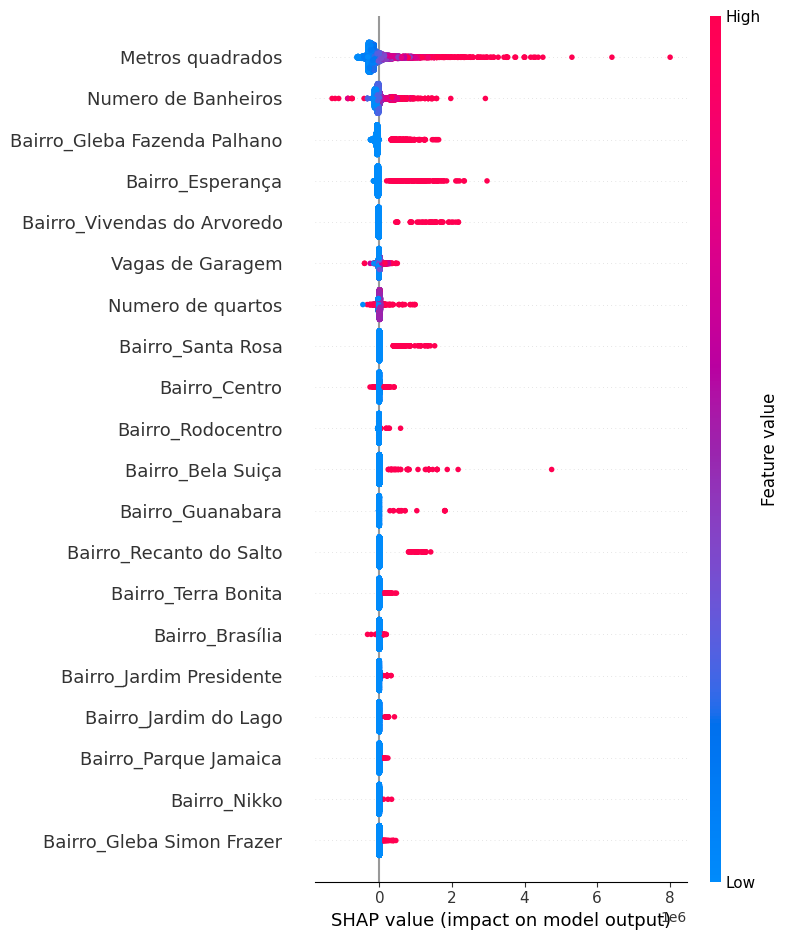

In [17]:
import shap

explainer = shap.Explainer(clf_random_forest_ohe, X_train_ohe)
shap_values = explainer(X_test_ohe)

shap.summary_plot(shap_values, X_test_ohe)

<p >Antes de falar sobre as features, irei explicar o gráfico acima: as cores representam o valor da feature, se o ponto estiver azul, o valor da feature é baixo, se estiver vermelha o valor dela é alto. Quanto mais a direita o ponto estiver, maior o valor do impacto no modelo, ou seja, quanto mais a direita, mais essa feature aumenta o preço que o modelo prevê. </p> 
<p>
    Podemos perceber que as features que mais impactaram o modelo foram:
</p>
<ul>
    <li>Metros Quadrados: <p>No gráfico observamos que quanto maior um imóvel, maior o seu preço e vice-versa, já que além de possuir pontos vermelhos mais a direita, ele também possui pontos azuis na esquerda, o que indica que valores baixos de M² abaixaram o valor do imóvel. Podemos ver também que o maior impacto no modelo foi essa feature, o que indica que a métrica mais importante para valorizar um imóvel é o tamanho total dele. </p>
    </li>
    <li>Número de Banheiros: <p>Podemos observar que a alta quantidade de banheiros pode não só aumentar o valor do preço do imóvel, mas também diminuir o preço dele. Isso indica que não há uma relação linear para essa feature e que o impacto dela depende de outras variáveis. Podemos observar no gráfico abaixo que o impacto do número de banheiros depende da quantidade de m² da casa, podemos ver no gráfico que quando temos uma casa menor, o impacto do número de banheiros não consegue ser tão alto, ele só consegue ter impacto quando há uma casa com muitos metros quadrados, o que indica que a métrica de metros quadrados é priorizada ao invés da métrica de número de banheiros.</p>
    </li>
    
</ul>


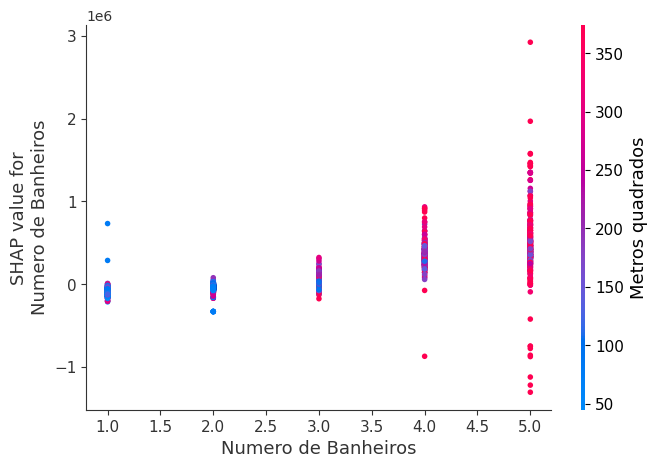

In [18]:
shap.dependence_plot("Numero de Banheiros", shap_values.values, X_test_ohe)


<ul>

<li>Número de Quartos: <p>Em um caso similar ao número de banheiros, podemos perceber que, apesar do maior número de quartos de fato influenciar no aumento do preço do imóvel, ele não parece ser tão linear, com alguns pontos indicando valores altos que diminuiram o valor da previsão. Ao analisar o gráfico abaixo sobre a relação de dependência dessa feature, pudemos perceber que o impacto dessa feature está bastante ligado com o tamanho da casa, assim como na feature de número de banheiros. Percebemos que quando a casa possui menos metros quadrados, o número de quartos não consegue impactar tanto no valor, já quando a casa é grande, o número de quartos possui um bom impacto no valor. Ou seja, o número de quartos importa mais se a casa for grande e age como um "critério de desempate" onde a prioridade são casas com maiores metros quadrados. Se a casa for pequena, a quantidade de banheiros não vai ser relevante para aumentar o preço.</p></li>
</ul>

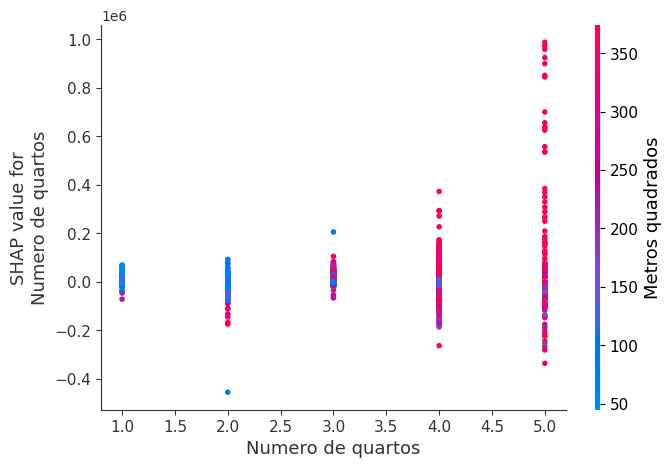

In [34]:
shap.dependence_plot("Numero de quartos", shap_values.values, X_test_ohe)


<ul>

<li>Features de Bairros do One Hot Encoding: <p>Todas as features que aparecem no primeiro gráfico são os bairros que mais possuem imóveis do dataset. Podemos perceber que o preço do imóvel depende do bairro onde ele está. Se ele está na Gleba Fazenda Palhano, ele tende a aumentar bastante o preço, se ele está no Centro, o preço dele não aumenta muito, podendo até diminuir em alguns casos. Isso acontece devido ao fato da Gleba Palhano possuir imóveis mais caros e o Centro mais baratos. Isso se repete para vários outros bairros também.</p></li>




</ul>    

<ul>

<li>Vagas de Garagem: <p>Podemos ver pelo primeiro gráfico que ela não possui muita linearidade, apesar de impactar no aumento do valor da previsão, ele também pode causar uma desvalorização no imóvel. Ao analisar o gráfico de dependência abaixo, percebemos que sua maior dependência é com a feature de bairro Centro. Isso indica que a variável da garagem está muito dependente se o imóvel é localizado no Centro ou não. Pelo gráfico, podemos ver que quando o imóvel está no centro, há uma desvalorização dele e que a feature só consegue impactar positivamente no valor do imóvel quando ela não está no Centro. Isso pode significar que quem mora no centro geralmente não está procurando vagas de garagem</p></li>

</ul>

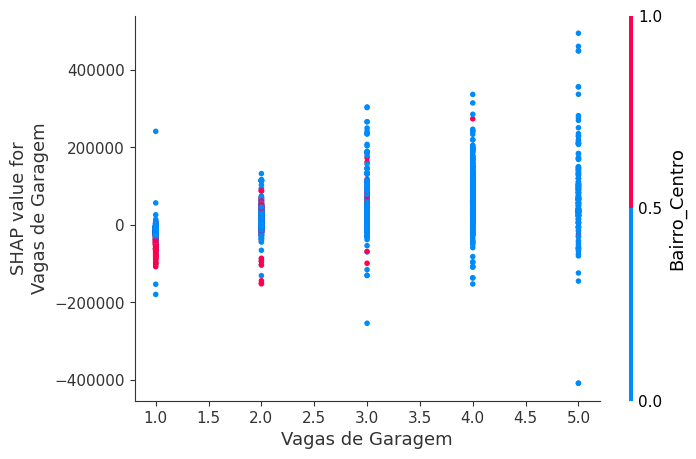

In [35]:
shap.dependence_plot("Vagas de Garagem", shap_values.values, X_test_ohe)


<p>Com isso, pudemos perceber que as features escolhidas conseguem explicar muito bem as previsões feitas e estão diretamente relacionadas com o preço de um imóvel.</p>